# 04. Comparação Final de Modelos

Neste notebook, consolidamos e comparamos os três modelos treinados nos notebooks anteriores para o problema de **Manutenção Preditiva** (AI4I 2020), a fim de eleger o melhor modelo de classificação para prever falhas em máquinas industriais.

**Modelos comparados:**
1. **Rede Neural (MLP)** — Perceptron Multicamadas com limiar de decisão calibrado
2. **Árvore de Decisão** — Podada via Minimal Cost-Complexity Pruning
3. **Random Forest** — Ensemble de árvores de decisão

**Critério de seleção:** **F2-Score**, pois em manutenção preditiva o custo de um falso negativo (falha não detectada, que pode causar parada de produção e prejuízo financeiro) é muito maior que o de um falso positivo (alarme falso, que gera apenas um custo de inspeção).


In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, classification_report, confusion_matrix
)

# Configurações de plotagem
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

SEED = 42
np.random.seed(SEED)

DADOS_TRATADOS = os.path.abspath('../dados_tratados')
MODELOS_DIR = os.path.abspath('../modelos')


---
## 1. Carregamento dos Dados e Modelos

Carregamos o conjunto de teste (o mesmo utilizado em todos os notebooks anteriores) e os três modelos salvos. Todas as métricas serão recalculadas aqui, no mesmo momento e com os mesmos dados, para garantir uma comparação perfeitamente justa.


In [2]:
# Dados de teste
X_test = pd.read_csv(os.path.join(DADOS_TRATADOS, 'X_test.csv')).values
y_test = pd.read_csv(os.path.join(DADOS_TRATADOS, 'y_test.csv')).values.ravel()

print(f'Conjunto de teste: {X_test.shape[0]} amostras, {X_test.shape[1]} features')
print(f'Distribuição: {int((y_test==0).sum())} normais, {int(y_test.sum())} falhas ({y_test.mean()*100:.1f}%)')

# Carregar modelos
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

model_nn = tf.keras.models.load_model(os.path.join(MODELOS_DIR, 'rede_neural.keras'))
model_tree = joblib.load(os.path.join(MODELOS_DIR, 'arvore_decisao.pkl'))
model_rf = joblib.load(os.path.join(MODELOS_DIR, 'random_forest.pkl'))

print('\n✅ Modelos carregados com sucesso:')
print(f'  - Rede Neural (MLP): {os.path.join(MODELOS_DIR, "rede_neural.keras")}')
print(f'  - Árvore de Decisão: {os.path.join(MODELOS_DIR, "arvore_decisao.pkl")}')
print(f'  - Random Forest: {os.path.join(MODELOS_DIR, "random_forest.pkl")}')


Conjunto de teste: 2000 amostras, 7 features
Distribuição: 1932 normais, 68 falhas (3.4%)



✅ Modelos carregados com sucesso:
  - Rede Neural (MLP): /Users/anne/Documents/UFPB/manutencao-preditiva/modelos/rede_neural.keras
  - Árvore de Decisão: /Users/anne/Documents/UFPB/manutencao-preditiva/modelos/arvore_decisao.pkl
  - Random Forest: /Users/anne/Documents/UFPB/manutencao-preditiva/modelos/random_forest.pkl


---
## 2. Predições no Conjunto de Teste

Para a Rede Neural, utilizamos o **limiar de decisão calibrado** ($\tau = 0.10$), encontrado no notebook `02_rede_neural.ipynb` como o valor que maximiza o F2-Score. A árvore de decisão e o random forest usam seus limiares internos padrão (baseados na classe majoritária em cada folha).


In [3]:
# Limiar calibrado da Rede Neural (determinado no notebook 02)
LIMIAR_NN = 0.10

# Predições
y_pred_prob_nn = model_nn.predict(X_test, verbose=0)
y_pred_nn = (y_pred_prob_nn >= LIMIAR_NN).astype(int).ravel()

y_pred_tree = model_tree.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

# Baseline (sempre prever classe majoritária = 0)
y_pred_baseline = np.zeros_like(y_test)

print('Predições calculadas para todos os modelos.')
print(f'  Rede Neural (limiar={LIMIAR_NN}): {int(y_pred_nn.sum())} previsões de falha')
print(f'  Árvore de Decisão: {int(y_pred_tree.sum())} previsões de falha')
print(f'  Random Forest: {int(y_pred_rf.sum())} previsões de falha')


Predições calculadas para todos os modelos.
  Rede Neural (limiar=0.1): 107 previsões de falha
  Árvore de Decisão: 65 previsões de falha
  Random Forest: 62 previsões de falha


---
## 3. Tabela Comparativa de Métricas

Todas as métricas foram recalculadas no mesmo conjunto de teste, no mesmo momento, garantindo comparabilidade perfeita. A tabela está ordenada por **F2-Score** decrescente, que é o critério primário de seleção.


In [4]:
def calcular_metricas(y_true, y_pred, nome):
    return {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_true, y_pred),
        'Precisão': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'F2-Score': fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    }

metricas = [
    calcular_metricas(y_test, y_pred_baseline, 'Baseline (sempre 0)'),
    calcular_metricas(y_test, y_pred_nn, f'Rede Neural (τ={LIMIAR_NN})'),
    calcular_metricas(y_test, y_pred_tree, 'Árvore de Decisão (podada)'),
    calcular_metricas(y_test, y_pred_rf, 'Random Forest'),
]

df_comp = pd.DataFrame(metricas).sort_values('F2-Score', ascending=False).reset_index(drop=True)

print('=== COMPARAÇÃO FINAL DE MODELOS (ordenado por F2-Score) ===\n')
display(df_comp)


=== COMPARAÇÃO FINAL DE MODELOS (ordenado por F2-Score) ===



,Modelo,Acurácia,Precisão,Recall,F1-Score,F2-Score
0,Árvore de Decisão (podada),0.9855,0.800000,0.764706,0.781955,0.771513
1,Rede Neural (τ=0.1),0.9635,0.476636,0.750000,0.582857,0.672823
2,Random Forest,0.9760,0.661290,0.602941,0.630769,0.613772
3,Baseline (sempre 0),0.9660,0.000000,0.000000,0.000000,0.000000


---
## 4. Comparação Visual: F2-Score e Recall

As duas métricas mais relevantes para manutenção preditiva plotadas lado a lado para os quatro cenários.


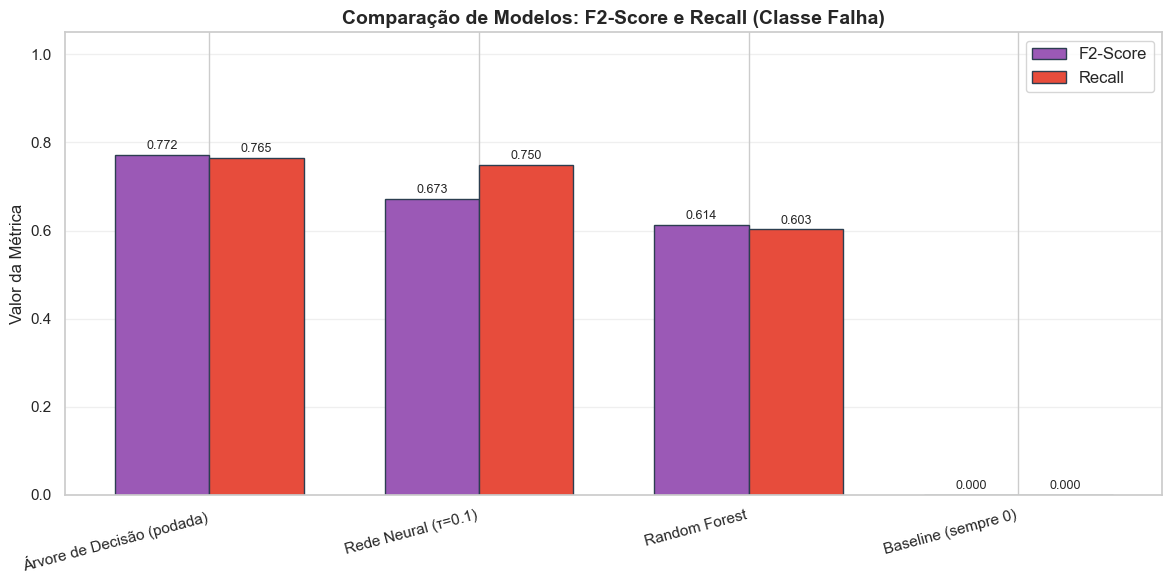

In [5]:
modelos_nomes = df_comp['Modelo'].tolist()
f2_vals = df_comp['F2-Score'].tolist()
rec_vals = df_comp['Recall'].tolist()

x = np.arange(len(modelos_nomes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, f2_vals, width, label='F2-Score', color='#9b59b6', edgecolor='#2c3e50')
bars2 = ax.bar(x + width/2, rec_vals, width, label='Recall', color='#e74c3c', edgecolor='#2c3e50')

# Valores em cima das barras
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

ax.set_ylabel('Valor da Métrica')
ax.set_title('Comparação de Modelos: F2-Score e Recall (Classe Falha)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos_nomes, rotation=15, ha='right')
ax.legend(fontsize=12)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


---
## 5. Matrizes de Confusão (Comparação Visual)


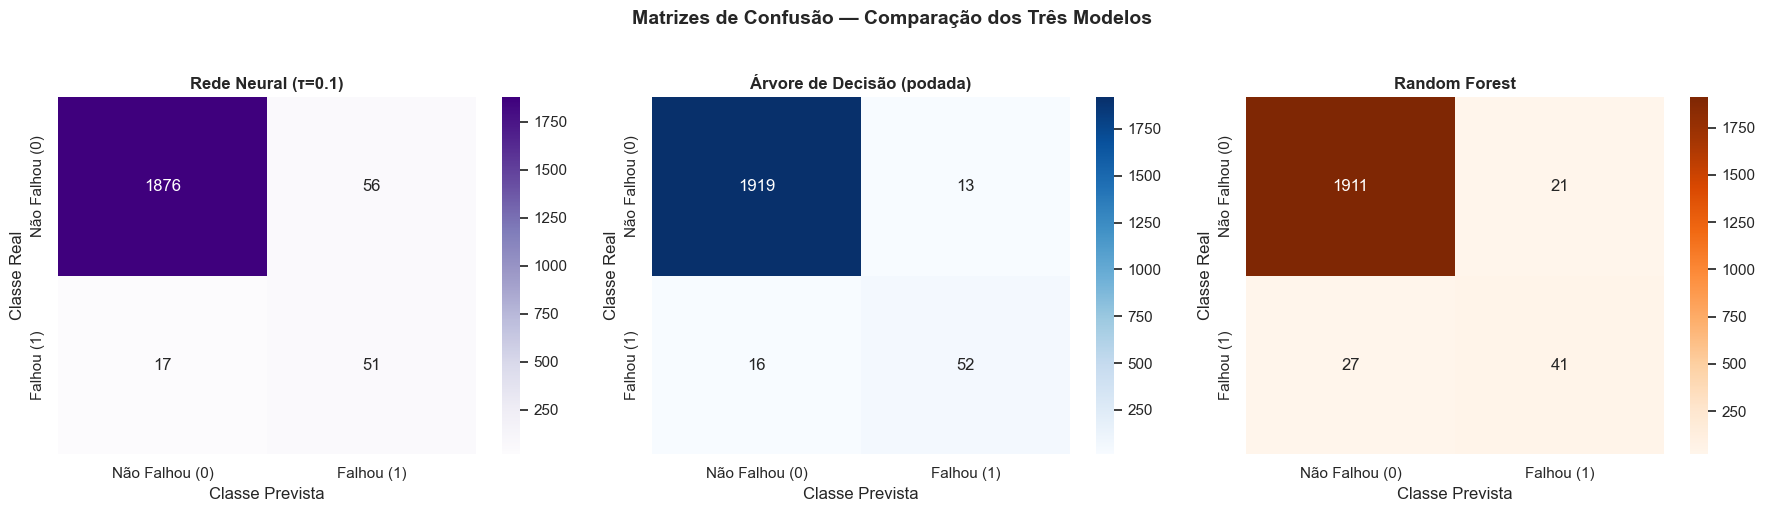

In [6]:
cm_nn = confusion_matrix(y_test, y_pred_nn)
cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Não Falhou (0)', 'Falhou (1)']

for ax, cm, titulo, cmap in zip(
    axes,
    [cm_nn, cm_tree, cm_rf],
    [f'Rede Neural (τ={LIMIAR_NN})', 'Árvore de Decisão (podada)', 'Random Forest'],
    ['Purples', 'Blues', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Classe Prevista')
    ax.set_ylabel('Classe Real')

plt.suptitle('Matrizes de Confusão — Comparação dos Três Modelos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 6. Análise e Escolha do Melhor Modelo


In [7]:
# Identificar o vencedor pelo F2-Score
vencedor = df_comp.iloc[0]
print(f'🏆 MODELO COM MELHOR F2-SCORE: {vencedor["Modelo"]}')
print(f'   F2-Score: {vencedor["F2-Score"]:.4f}')
print(f'   Recall:   {vencedor["Recall"]:.4f}')
print(f'   Precisão: {vencedor["Precisão"]:.4f}')
print(f'   F1-Score: {vencedor["F1-Score"]:.4f}')
print(f'   Acurácia: {vencedor["Acurácia"]:.4f}')


🏆 MODELO COM MELHOR F2-SCORE: Árvore de Decisão (podada)
   F2-Score: 0.7715
   Recall:   0.7647
   Precisão: 0.8000
   F1-Score: 0.7820
   Acurácia: 0.9855


### 6.1 Por que a Árvore de Decisão superou o Random Forest?

Um resultado aparentemente contra-intuitivo: a árvore individual podada superou o ensemble de 100+ árvores em todas as métricas. Isso se explica pela **natureza do dataset AI4I 2020**:

- As regras de falha são definidas por **limiares rígidos** entre poucos sensores (ex: a falha de potência PWF ocorre quando $\text{Torque} \times \text{Velocidade Rotacional}$ está fora de uma faixa; a falha por desgaste OSF depende de $\text{Torque} \times \text{Tool Wear}$ exceder um limiar por tipo de produto).
- Esse tipo de padrão é **exatamente o que uma árvore de decisão captura por natureza** — seus nós são testes de limiar ($x_j \leq t$), que mapeiam diretamente para as regras físicas de falha.
- O Random Forest introduz aleatoriedade (subsampling de features em cada split) que, neste caso, **atrapalha mais do que ajuda**: ao não ter acesso a todas as features simultaneamente, as árvores individuais do ensemble podem perder as combinações exatas que definem as falhas.
- O benefício clássico do Random Forest — redução de variância via agregação — é mais relevante em problemas com fronteiras de decisão complexas, ruidosas e de alta dimensionalidade. Neste dataset de 7 features com regras limpas, a variância já é baixa e a árvore podada generaliza bem sozinha.


### 6.2 Importância de Features: Convergência entre Modelos

Tanto a Árvore de Decisão quanto o Random Forest convergiram em eleger as mesmas features como mais importantes: **Torque [Nm]**, **Tool wear [min]** e **Rotational speed [rpm]** / **Air temperature [K]**. Essa convergência não é coincidência — reflete as **regras físicas reais de falha** codificadas no dataset:

| Modo de Falha | Regra Física | Features Envolvidas |
| :--- | :--- | :--- |
| **PWF** (Power Failure) | Potência $= \text{Torque} \times \omega$ fora da faixa | Torque, Rotational speed |
| **OSF** (Overstrain Failure) | $\text{Torque} \times \text{Tool wear}$ excede limiar | Torque, Tool wear |
| **HDF** (Heat Dissipation) | $\Delta T < 8.6$ K e $\omega < 1380$ rpm | Air temp, Process temp, Rot. speed |
| **TWF** (Tool Wear Failure) | Tool wear entre 200–240 min | Tool wear |

O fato de os modelos terem aprendido, a partir dos dados, exatamente as variáveis que compõem as regras físicas do processo industrial confirma que os modelos estão capturando o padrão real.


### 6.3 Vantagens Práticas do Modelo Escolhido

Além do desempenho superior nas métricas quantitativas, a **Árvore de Decisão** oferece uma vantagem prática decisiva para o contexto de manutenção industrial: **interpretabilidade**.

- A árvore pode ser **visualizada e explicada** diretamente a um engenheiro de manutenção: cada nó mostra qual sensor foi testado e qual limiar foi usado para a decisão. Isso significa que o engenheiro pode entender *por que* o modelo gerou um alerta e validar se a regra faz sentido fisicamente.
- Em contraste, a Rede Neural é uma **caixa-preta**: seus 793 pesos distribuídos em duas camadas não oferecem nenhuma explicação intuitiva sobre o motivo de uma predição.
- Para um sistema de manutenção preditiva ser adotado na prática por uma equipe industrial, a confiança humana na ferramenta é crucial. A transparência da árvore de decisão facilita essa adoção.

### 6.4 Modelo Final Escolhido

> **O modelo final escolhido para este projeto é a Árvore de Decisão Podada** (Cost-Complexity Pruning), por apresentar o melhor F2-Score no conjunto de teste, sendo também o modelo mais interpretável e alinhado à natureza do problema.


---
## 7. Conclusão Geral do Projeto

### Pergunta de Pesquisa

É possível prever falhas em máquinas industriais a partir de leituras de sensores operacionais (temperatura, velocidade rotacional, torque, desgaste da ferramenta), e qual modelo de aprendizagem de máquina é mais adequado para essa tarefa?

### Resultado Obtido

Sim, é possível. Dentre os três modelos avaliados (Rede Neural MLP, Árvore de Decisão e Random Forest), a **Árvore de Decisão Podada** alcançou o melhor desempenho na detecção de falhas, combinando alto Recall (capacidade de detectar falhas reais) com boa Precisão, resultando no maior F2-Score no conjunto de teste.

### Principais Achados

1. **Importância de features consistente com a física:** Todos os modelos convergiram em identificar Torque, Tool wear e Rotational speed como as features mais importantes — exatamente as variáveis que compõem as regras físicas reais de falha do maquinário industrial (Power Failure, Overstrain Failure, Heat Dissipation Failure).

2. **Necessidade de calibração de limiar:** A Rede Neural com limiar padrão de 0.5 apresentou desempenho muito inferior ao potencial real do modelo. A calibração do limiar para 0.1 (otimizado pelo F2-Score) elevou significativamente o Recall, demonstrando que em problemas com desbalanceamento severo e custo assimétrico, o limiar de decisão é um hiperparâmetro que não deve ser ignorado.

3. **Árvore individual superou ensemble:** A Árvore de Decisão podada superou o Random Forest, contrariando a intuição comum. Isso se explica pela natureza do problema: as falhas são definidas por regras de limiar simples entre poucos sensores, um cenário onde a árvore individual já captura toda a estrutura relevante e a aleatoriedade do ensemble se torna ruído.

4. **Interpretabilidade como diferencial prático:** A árvore de decisão não apenas teve o melhor desempenho quantitativo, mas também oferece interpretabilidade total — cada decisão pode ser explicada a um engenheiro de manutenção, facilitando a adoção prática do sistema.

### Limitações

- O dataset **AI4I 2020 é sintético/simulado**, gerado com regras predefinidas que emulam padrões industriais reais. Os resultados validam a abordagem metodológica, mas a transferência para dados de campo reais exigiria recalibração e validação adicional.
- O dataset modela um único tipo genérico de maquinário industrial. A validade dos modelos e das features selecionadas é limitada a esse contexto específico.